<a href="https://colab.research.google.com/github/rifkiabdulaziz-lab/analis_aplikasi_pos_aja/blob/main/rifki_abdul_aziz_14022300038_aplikasi__pos_aja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
pip install google-play-scraper

In [75]:
!pip install google-play-scraper

import os
from google_play_scraper import reviews, Sort
import csv

app_id = 'com.posindonesia.cob'
result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=90,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'
file_path = os.path.join(os.getcwd(), filename)

try:
    with open(file_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
        writer.writeheader()
        for review in result:
            writer.writerow({
                'userName': review['userName'],
                'score': review['score'],
                'at': review['at'],
                'content': review['content']
            })
    print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")
    if os.path.exists(file_path):
        print(f"Verifikasi: File '{filename}' berhasil dibuat di: {file_path}")
    else:
        print(f"Peringatan: File '{filename}' TIDAK DITEMUKAN setelah upaya penyimpanan!")
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan ulasan ke '{filename}': {e}")

Berhasil menyimpan 90 ulasan ke 'ulasan_google_play.csv'
Verifikasi: File 'ulasan_google_play.csv' berhasil dibuat di: /content/ulasan_google_play.csv


In [76]:
pip install transformers

In [77]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df_reviews = pd.read_csv('ulasan_google_play.csv')

In [78]:
# Initialize a sentiment analysis pipeline
# Using a multilingual model that supports Indonesian
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [79]:
print(f"DataFrame contains {len(df_reviews)} rows.")
print("Menampilkan 10 baris pertama untuk verifikasi:")
display(df_reviews.head(10))

DataFrame contains 90 rows.
Menampilkan 10 baris pertama untuk verifikasi:


,userName,score,at,content
0,Soleh S,1,2026-04-29 10:23:42,"scan barcode tidak bisa bisanya di Web, itupun..."
1,Ama No,1,2026-04-28 14:48:01,"jangan di download, karena ini aplikasi Sampah..."
2,SAMSUL RIJAL,5,2026-04-27 03:58:46,bagai mana cara menggunakan poin yang sudah ka...
3,Uman Rukmana,1,2026-04-26 23:00:45,ribet mau cek tarif aja susah udah cape ngisi ...
4,Eko Dwi Istiyanto,1,2026-04-25 15:07:48,"Ya beginilah kwalitas BUMN di negeri ini, gima..."
5,fanny skylar,1,2026-04-25 08:58:26,2 kali beli paket pengiriman pake pos lama ban...
6,Steady Flashing,1,2026-04-24 05:34:14,"Pelayanan PoS ID yang sangat lambat, lelet, ku..."
7,Jacknaf Walker,5,2026-04-23 09:04:33,baru di coba dulu
8,Aing Macan Aing Macan,5,2026-04-23 01:39:28,"pos Indonesia semakin mudah semakin inovatif,,..."
9,Rizki Ramadhan,1,2026-04-22 03:06:47,"pesen pick ip dirumah, gaada yang ngambil. tib..."


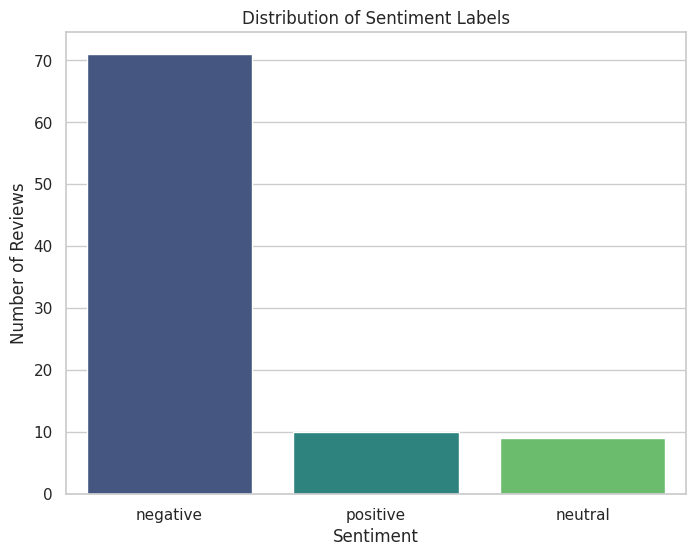

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX: Apply sentiment analysis to create the 'sentiment' column ---
df_reviews['sentiment'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['label'])
df_reviews['sentiment_score'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['score'])
# ----------------------------------------------------------------------

# Calculate the distribution of sentiment labels
sentiment_counts = df_reviews['sentiment'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()